<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/banner_cd.png">

# Proyecto de Machine Learning:  Prediccion de precios de casas

	
Pasos principales que deberá seguir:


1. Mira el panorama general y entienda el problema.
* Obtenga los datos.
* Descubra y visualice los datos para obtener información.
* Prepare los datos para los algoritmos de Machine Learning.
* Seleccione un modelo y realice el entrenamiento (train).
* Afina(fine tune) el modelo.
* Presente su solución.
* Inicie (Launch), monitoree y mantenga su sistema
(https://bit.ly/2Sqtfhl)

## 1. Introducción

#  USA Housing Dataset

El **USA Housing Dataset** contiene información socioeconómica y demográfica de distintas áreas residenciales en Estados Unidos, con el propósito de analizar los factores que influyen en el **precio promedio de las viviendas**.  

Este conjunto de datos es comúnmente utilizado para **modelos de regresión**, **análisis exploratorio de datos (EDA)** y **aprendizaje automático supervisado**, especialmente para ejercicios de predicción de precios inmobiliarios.

---

##  Archivo

- **Ruta:** `USA_Housing.csv`  
- **Tamaño:** 319 KB  
- **Número de registros:** 5001  
- **Número de variables:** 6

---

##  Descripción de las columnas

| Columna | Descripción | Tipo de dato |
|----------|--------------|---------------|
| `Area Income` | Ingreso promedio anual de los residentes en el área | Numérico (float) |
| `Area House Age` | Edad promedio de las viviendas en el área (en años) | Numérico (float) |
| `Area No of Rooms` | Promedio de habitaciones por vivienda en el área | Numérico (float) |
| `Area No of Bedrooms` | Promedio de dormitorios por vivienda en el área | Numérico (float) |
| `Area Population` | Población promedio del área | Numérico (float) |
| `Price` | Precio promedio de las viviendas (variable objetivo) | Numérico (float) |

---

## Objetivo del dataset

El objetivo principal es **predecir el precio de las viviendas (`Price`)** a partir de las características demográficas y estructurales del área.  
Este dataset es ideal para practicar técnicas de:

- Regresión lineal y múltiple  
- Selección y normalización de características  
- Evaluación de modelos predictivos  
- Visualización de correlaciones socioeconómicas  

---


## 2. Obtenga los datos

In [1]:
#Librerias principales
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
#Cargar el archivo "datos/USA_Housing_Train.txt"
df = pd.read_csv("datos/USA_Housing_Train.txt")

## 3. Descubra y visualice los datos para obtener información.


In [3]:
# Mostrar los primeras filas
df.head()

,Area Income,Area House Age,Area No of Rooms,Area No of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


In [4]:
#Información general 
df.describe()

,Area Income,Area House Age,Area No of Rooms,Area No of Bedrooms,Area Population,Price
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03
mean,68561.764989,5.982444,6.989255,3.974775,36279.220348,1.235349e+06
std,10693.493261,0.990669,1.004391,1.231435,9899.991119,3.544019e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61474.294678,5.334776,6.308615,3.140000,29550.400770,9.997036e+05
50%,68655.504150,5.969464,7.001368,4.045000,36240.428580,1.237303e+06
75%,75781.049625,6.663936,7.665612,4.490000,43000.807275,1.469933e+06
max,107701.748400,9.519088,10.759588,6.500000,69592.040240,2.469066e+06


In [5]:
# Mostrar el número de filas y columnas
df.shape

(4000, 6)

In [6]:
# Mostrar el tipo de variables
df.dtypes

Area Income            float64
Area House Age         float64
Area No of Rooms       float64
Area No of Bedrooms    float64
Area Population        float64
Price                  float64
dtype: object

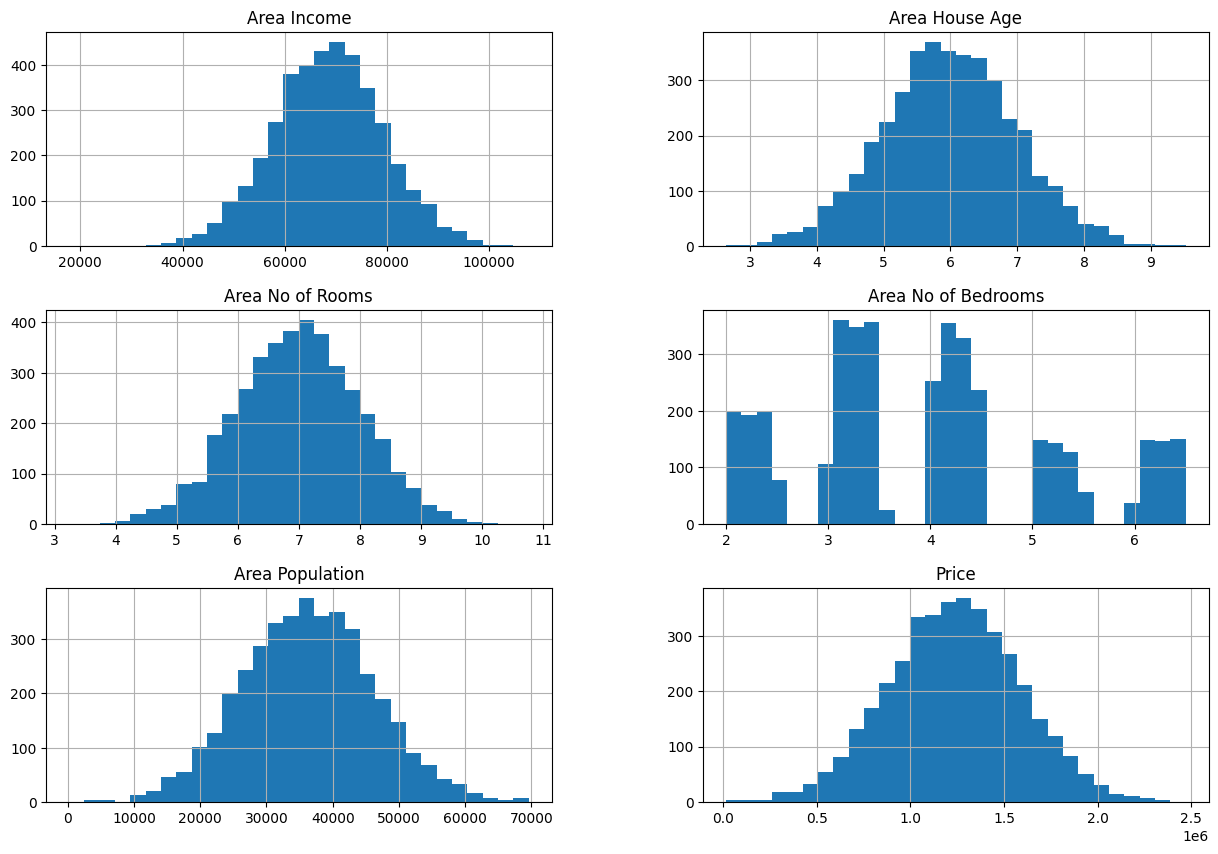

In [7]:
#Graficar todas las variables numericas 
df.hist(bins=30, figsize=(15,10))
plt.show()

### Correlación de variables

In [8]:
df.columns

Index(['Area Income', 'Area House Age', 'Area No of Rooms',
       'Area No of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

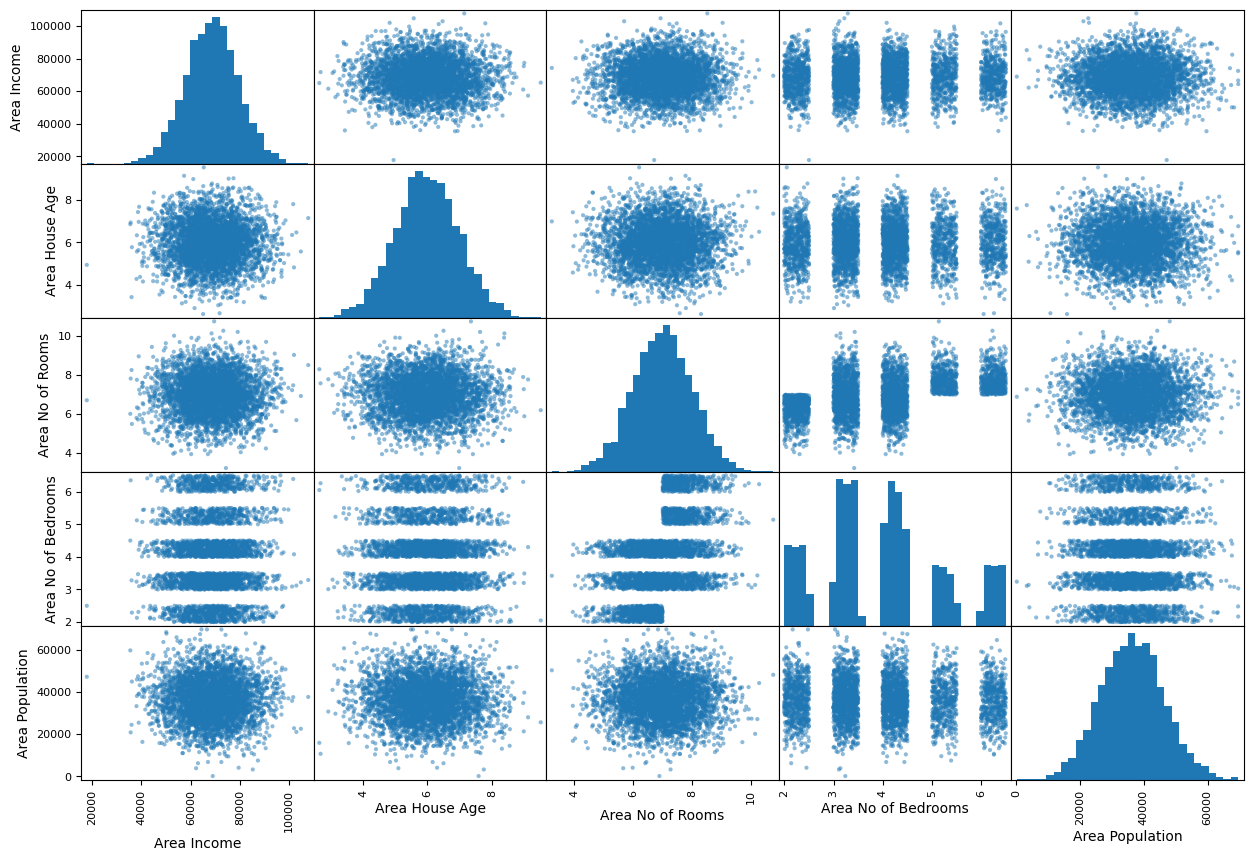

In [9]:
#Hacer diagramas de correlación
# Definir una lista llamada atributos  con las siguientes variables : 
#'Area Income', 'Area House Age', 'Area No of Rooms','Area No of Bedrooms', 'Area Population'
from pandas.plotting import scatter_matrix

atributos = ['Area Income', 'Area House Age', 'Area No of Rooms',
       'Area No of Bedrooms', 'Area Population']

scatter_matrix(df[atributos], 
               figsize=(15, 10), 
               hist_kwds= { "bins": 30 })
plt.show()

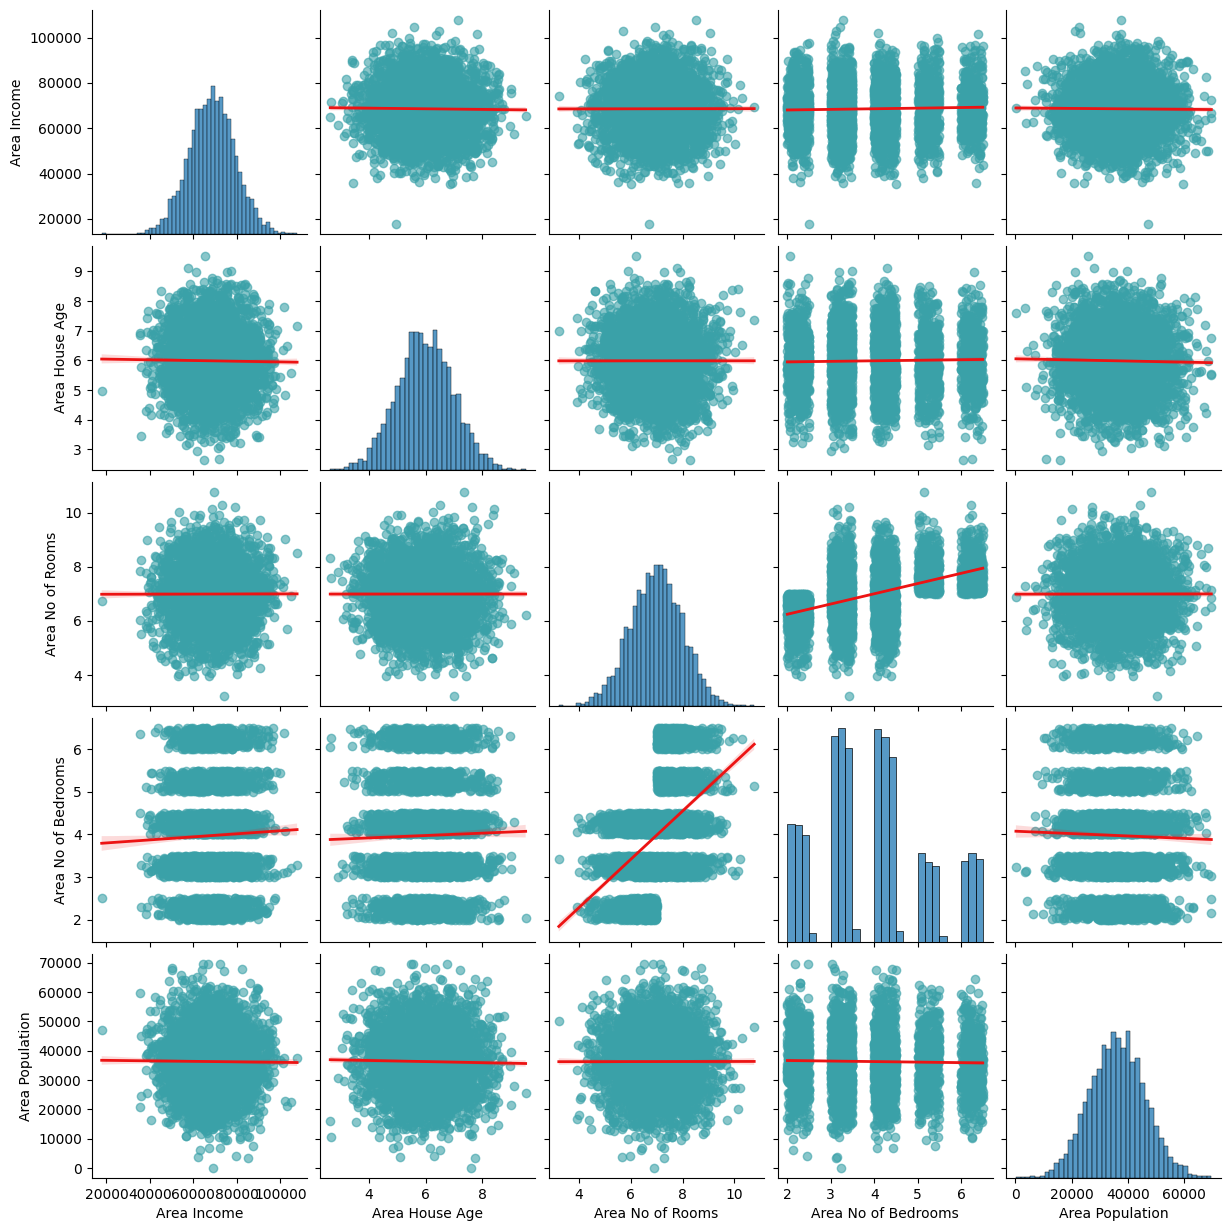

In [10]:
#Con seaborn para ver posibles rergesiones lineales
sns.pairplot(df[atributos], kind='reg',
    plot_kws={'scatter_kws': {'color': "#3AA1A8", 'alpha': 0.6}, 
              'line_kws': {'color': "#EC1313", 'lw': 2}})
plt.show()

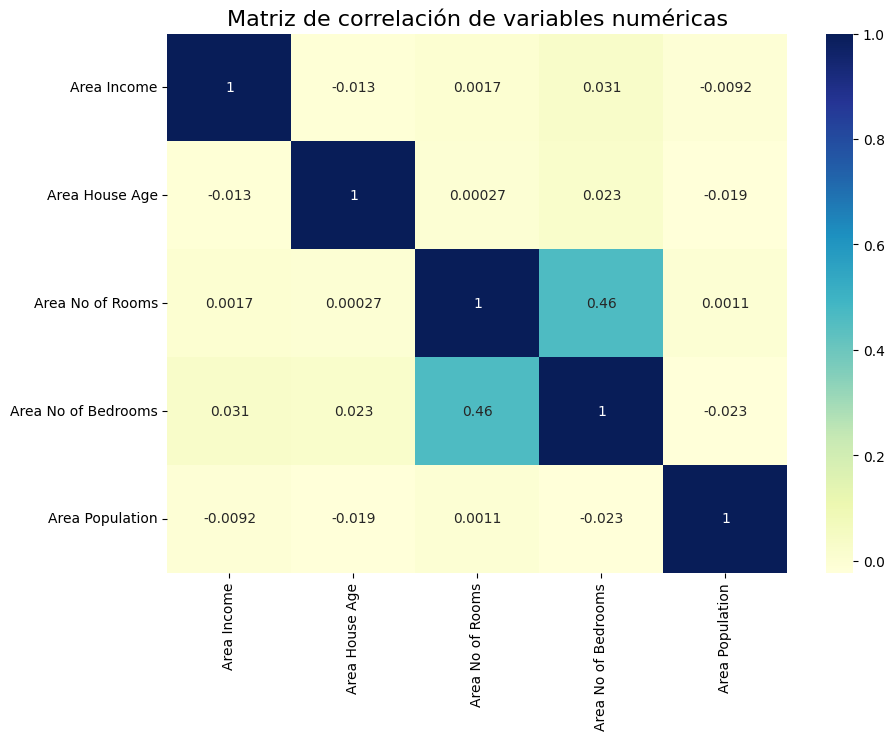

In [11]:
# Matriz correlación númerica y visual
#https://matplotlib.org/tutorials/colors/colormaps.html
#Instalación de seaborn
#pip install seaborn
import seaborn as sn
import seaborn as sn
correlation_matrix = df[atributos].corr()
plt.figure(figsize=(10,7))
sn.heatmap(correlation_matrix, annot=True, cmap='YlGnBu')
plt.title('Matriz de correlación de variables numéricas', fontsize=16)
plt.show()

## 4. Prepare los datos y sus transformadores 

In [12]:
#Revisar si hay datos perdidos NaN
any( df.isna() )

True

In [13]:
#Número de filas
len(df)

4000

In [14]:
# eliminar datos  perdidos NaN
df.dropna(inplace=True)

In [15]:
len(df)

4000

###  ColumnTransformer  y pipeline

<img src="figuras/pipeline.jpg" align="middle" style="width:500px;" />

#### Pipeline

La función pipeline permite juntar varios trasformaciones secuenciales que se requieren ejecutar a un conjunto de datos.

**Pipeline(steps=[('titulo trasnformación1', trasnformación1), ('titulo trasnformación2', trasnformación2),...])**




In [16]:
#Modulos importantes
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [17]:
# Crear la lista de  viriables numericas y categoricas
# 'Area Income', 'Area House Age', 'Area No of Rooms', 'Area No of Bedrooms', 'Area Population'
lista_num=['Area Income', 'Area House Age', 'Area No of Rooms','Area No of Bedrooms', 'Area Population']


In [18]:
# Mostrar las columnas del dataframe
df.columns

Index(['Area Income', 'Area House Age', 'Area No of Rooms',
       'Area No of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

In [19]:
# Crear el pipeline de preprocesamiento para datos numéricos y categóricos.
transformacion_num =Pipeline( [ ( 'scaler' , StandardScaler()  ) ] )

#### ColumnTransformer


ColumnTransformer es una clase de scikit-learn que  permite aplicar transformaciones de preparación de datos de forma selectiva.

Por ejemplo,  permite aplicar una transformación específica o secuencia de transformaciones solo a las columnas numéricas, y una secuencia separada de transformaciones solo a las columnas categóricas.

Para usar ColumnTransformer, debe especificar una lista de transformadores.

Cada transformador es una tupla de tres elementos que define el nombre del transformador, la transformación a aplicar y los índices de columna a los que aplicar. Por ejemplo: **(Nombre, objeto, columnas)**

In [20]:
# Definir los transformadores
transformacion = ColumnTransformer( [ ('num', transformacion_num, lista_num)  ]   )

### Preparando las muestras de entrenamiento y prueba

<img  align="middle" style="width:550px;" src="figuras/ml_diagrama3.jpg">


División general de los datos
* **X**: Datos  sin la columna "median_house_value""
* **y**: Datos con la columna "median_house_value"

Muestras de entrenamiento y prueba
* **X_train**: este será el grupo de entrenamiento
* **X_test**: este será el  grupo de prueba
* **y_train**: este será el target para el grupo de entrenamiento
* **y_test**: este será el target para el grupo de prueba


In [21]:
# Crear X (Quitar la columna o campo de "Price")
X=df.drop('Price', axis=1)  
X.head(2)

,Area Income,Area House Age,Area No of Rooms,Area No of Bedrooms,Area Population
0,79545.45857,5.682861,7.009188,4.09,23086.80050
1,79248.64245,6.002900,6.730821,3.09,40173.07217


In [22]:
# Crear y (Valor de de la columna "Price")
y=df['Price']
y.head(2)

0    1059033.558
1    1505890.915
Name: Price, dtype: float64

In [23]:
# Dividir los datos para entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 ) 

In [24]:
# Revise  el tamaño de cada muestra
print(  len(X) ,  len(X) *0.8 , len(X) *0.2     )

print( len(X_train) )
print( len(X_test) )
print( len(y_test) )
print( len(y_train) )

4000 3200.0 800.0
3200
800
800
3200


## 6 .  Afina(fine tune) el modelo RandomForest


## Hyperparámetros clave para RandomForestRegressor (scikit-learn)

A la hora de optimizar  un **Random Forest** para regresión, estos son los parámetros más útiles y algunas bandas de valores para probar.

## 1. `n_estimators`
- **Qué es:** número de árboles en el bosque.
- **Efecto:** más árboles → mejor desempeño (hasta cierto punto) pero más tiempo de cómputo.
- **Probar:** `100, 200, 300, 500, 800, 1000`

## 2. `max_depth`
- **Qué es:** profundidad máxima de cada árbol.
- **Efecto:** sin límite (`None`) los árboles crecen mucho y pueden sobreajustar; limitar la profundidad controla el overfitting.
- **Probar:** `None, 5, 8, 10, 15, 20`

## 3. `min_samples_split`
- **Qué es:** número mínimo de muestras para dividir un nodo.
- **Efecto:** valores pequeños → árboles más complejos; valores más grandes → modelo más general.
- **Probar:** `2, 5, 10`

## 4. `min_samples_leaf`
- **Qué es:** mínimo de muestras en una hoja.
- **Efecto:** subir este valor suaviza las predicciones y reduce overfitting, sobre todo con pocos datos.
- **Probar:** `1, 2, 4, 5`

## 5. `max_features`
- **Qué es:** cuántas variables se consideran al buscar la mejor división.
- **Efecto:** menos features por división → más diversidad entre árboles → a veces mejor generalización.
- **Probar:** `"auto"` (o `"sqrt"`), `"log2"`, `0.5` (50% de las features)

In [25]:
#Aplicar el modelo RandomForestRegressor
from sklearn.ensemble  import RandomForestRegressor

In [26]:
#1. Nombrar una variable para nuestro modelo
RF_regression = RandomForestRegressor()

In [27]:
RF_regression.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [28]:
#2. Definir el Pipeline : Transformación  + modelo
modelo_RF = Pipeline( [  ( 'transformer' , transformacion )  ,
                                  ('RF_regression', RF_regression )   ]   )

In [29]:
# Utilizamos la función GridSearchCV para encontrar los valores optimos
from sklearn.model_selection import GridSearchCV

In [30]:
#Definición de posibles parametros
n_estimators=[ 80 , 120, 180]
min_samples_split=[7,10 , 15]
max_depth=[6,10  ]
parametros = { 
'RF_regression__n_estimators': n_estimators,    
'RF_regression__min_samples_split': min_samples_split,    
'RF_regression__max_depth': max_depth       
}

In [31]:
#Definicion del grid de busqueda
grid_RF = GridSearchCV( modelo_RF, param_grid = parametros,
                       cv=5 , scoring='neg_mean_squared_error',
                       n_jobs=-1 , verbose=2 )

In [32]:
# Ajuste del modelo usando todas las posibles combinaciones de parametros 
grid_RF.fit( X,y)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'RF_regression__max_depth': [6, 10], 'RF_regression__min_samples_split': [7, 10, ...], 'RF_regression__n_estimators': [80, 120, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [33]:
# Mostrar la mejor combinación
print( grid_RF.best_params_ )

{'RF_regression__max_depth': 10, 'RF_regression__min_samples_split': 7, 'RF_regression__n_estimators': 180}


**Encontramos los nuevos valores de la media y desviación estándar**


In [34]:
#1 Ajustar el modelo con los nuevos parametros 
RF_regression_tunned = RandomForestRegressor( n_estimators=180,
                                                min_samples_split=7,
                                                max_depth=10,
                                                random_state=42 )

In [35]:
#2. Definir el Pipeline : Transformación  + modelo
modelo_RF_tunned = Pipeline(  [  (  'transformer' , transformacion  ) ,
                                   (  'RF_regression_tunned', RF_regression_tunned )  ] )

In [36]:
#3. Ajustar el modelo
modelo_RF_tunned.fit( X,y)

,steps,"[('transformer', ...), ('RF_regression_tunned', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
from sklearn.model_selection import cross_val_score

# 4. Calcular el score con la validación cruzada CV=5
cv_RF_tunned = cross_val_score( modelo_RF_tunned, X,y, 
                               scoring='neg_mean_squared_error',
                               cv=5)
cv_RF_tunned

array([-1.33549256e+10, -1.63920165e+10, -1.46608015e+10, -1.53038036e+10,
       -1.47064114e+10])

In [38]:
# 5. Realizar el cambio de signo y sacar la raiz
rmse_RF_tunned = np.sqrt( -cv_RF_tunned  )
rmse_RF_tunned

array([115563.51341298, 128031.31057868, 121081.79660181, 123708.54287939,
       121269.99380686])

In [39]:
# 6. Mostrar el resultado usando la funcion display_scores
media_RF_tunned = rmse_RF_tunned.mean()
std_RF_tunned = rmse_RF_tunned.std()
print(   media_RF_tunned , std_RF_tunned )

121931.0314559429 4051.577689599267


# Guardar el modelo entrenado

In [40]:
import joblib

In [41]:
joblib.dump(modelo_RF_tunned, 'modelos/modelo_RF_tunned.joblib')

['modelos/modelo_RF_tunned.joblib']